# Modélisation 

### Import des modules 

In [163]:
# Bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Preprocess
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

### Import des données

In [164]:
# Charger les données nettoyées
building_consumption_featured = pd.read_csv('../sources/2016_Building_Energy_Benchmarking_02_featured.csv')

#print(f"Dataset original : {building_consumption_featured.shape}")
#print(f"\nAperçu des données :")
#display(building_consumption_featured.head())
#print(f"\nTypes de données :")
#display(building_consumption_featured.dtypes)

# Traget a analyser
target = 'SiteEnergyUse(kWh)'

---

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

---

### 1. Analyse de la distribution de la cible

La variable cible est **`SiteEnergyUse(kWh)`** qui représente la consommation énergétique totale du bâtiment.

In [165]:
# Fonction pour analyser la target
def analyser_distribution_cible(dataframe, target_column='SiteEnergyUse(kWh)'):    
    # Statistiques descriptives
    print("Statistiques descriptives :")
    print(dataframe[target_column].describe())
    print(f"\nMédiane : {dataframe[target_column].median():,.0f} kWh")
    print(f"Écart-type : {dataframe[target_column].std():,.0f} kWh")
    
    # Graphiques
 
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Histogramme de la distribution
    axes[0, 0].hist(dataframe[target_column], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].set_title('Distribution de la consommation énergétique', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('SiteEnergyUse (kWh)')
    axes[0, 0].set_ylabel('Fréquence')
    axes[0, 0].axvline(dataframe[target_column].mean(), color='red', linestyle='--', linewidth=2, 
                        label=f'Moyenne: {dataframe[target_column].mean():,.0f}')
    axes[0, 0].axvline(dataframe[target_column].median(), color='green', linestyle='--', linewidth=2, 
                        label=f'Médiane: {dataframe[target_column].median():,.0f}')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Boxplot pour détecter les outliers
    axes[0, 1].boxplot(dataframe[target_column], vert=True)
    axes[0, 1].set_title('Boxplot - Détection des outliers', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('SiteEnergyUse (kWh)')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Distribution logarithmique
    axes[1, 0].hist(np.log1p(dataframe[target_column]), bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 0].set_title('Distribution logarithmique (log1p)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('log(SiteEnergyUse + 1)')
    axes[1, 0].set_ylabel('Fréquence')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. Q-Q plot pour vérifier la normalité
    stats.probplot(dataframe[target_column], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot - Test de normalité', fontsize=14, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Retourner les statistiques importantes
    return {
        'mean': dataframe[target_column].mean(),
        'median': dataframe[target_column].median(),
        'std': dataframe[target_column].std()
    }

In [166]:
# Fonction pour analyser les outliers
def analyser_outliers(dataframe, target_column='SiteEnergyUse(kWh)'):
    # Analyse des outliers
    Q1 = dataframe[target_column].quantile(0.25)
    Q3 = dataframe[target_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[target_column] < lower_bound) | (dataframe[target_column] > upper_bound)]

    print(f"Q1 (25%) : {Q1:,.0f} kWh")
    print(f"Q3 (75%) : {Q3:,.0f} kWh")
    print(f"IQR : {IQR:,.0f} kWh")
    print(f"Borne inférieure : {lower_bound:,.0f} kWh")
    print(f"Borne supérieure : {upper_bound:,.0f} kWh")
    print(f"\nNombre d'outliers détectés : {len(outliers)} ({len(outliers)/len(dataframe)*100:.2f}%)")
    
    if len(outliers) > 0:
        print(f"Valeur min des outliers : {outliers[target_column].min():,.0f} kWh")
        print(f"Valeur max des outliers : {outliers[target_column].max():,.0f} kWh")
    
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'nb_outliers': len(outliers),
        'pct_outliers': len(outliers)/len(dataframe)*100,
    }

=== ANALYSE DE LA VARIABLE CIBLE : SiteEnergyUse(kWh) ===

Statistiques descriptives :
count    1.441000e+03
mean     2.279472e+06
std      5.615805e+06
min      1.674409e+04
25%      3.569934e+05
50%      7.739949e+05
75%      2.040382e+06
max      8.589643e+07
Name: SiteEnergyUse(kWh), dtype: float64

Médiane : 773,995 kWh
Écart-type : 5,615,805 kWh


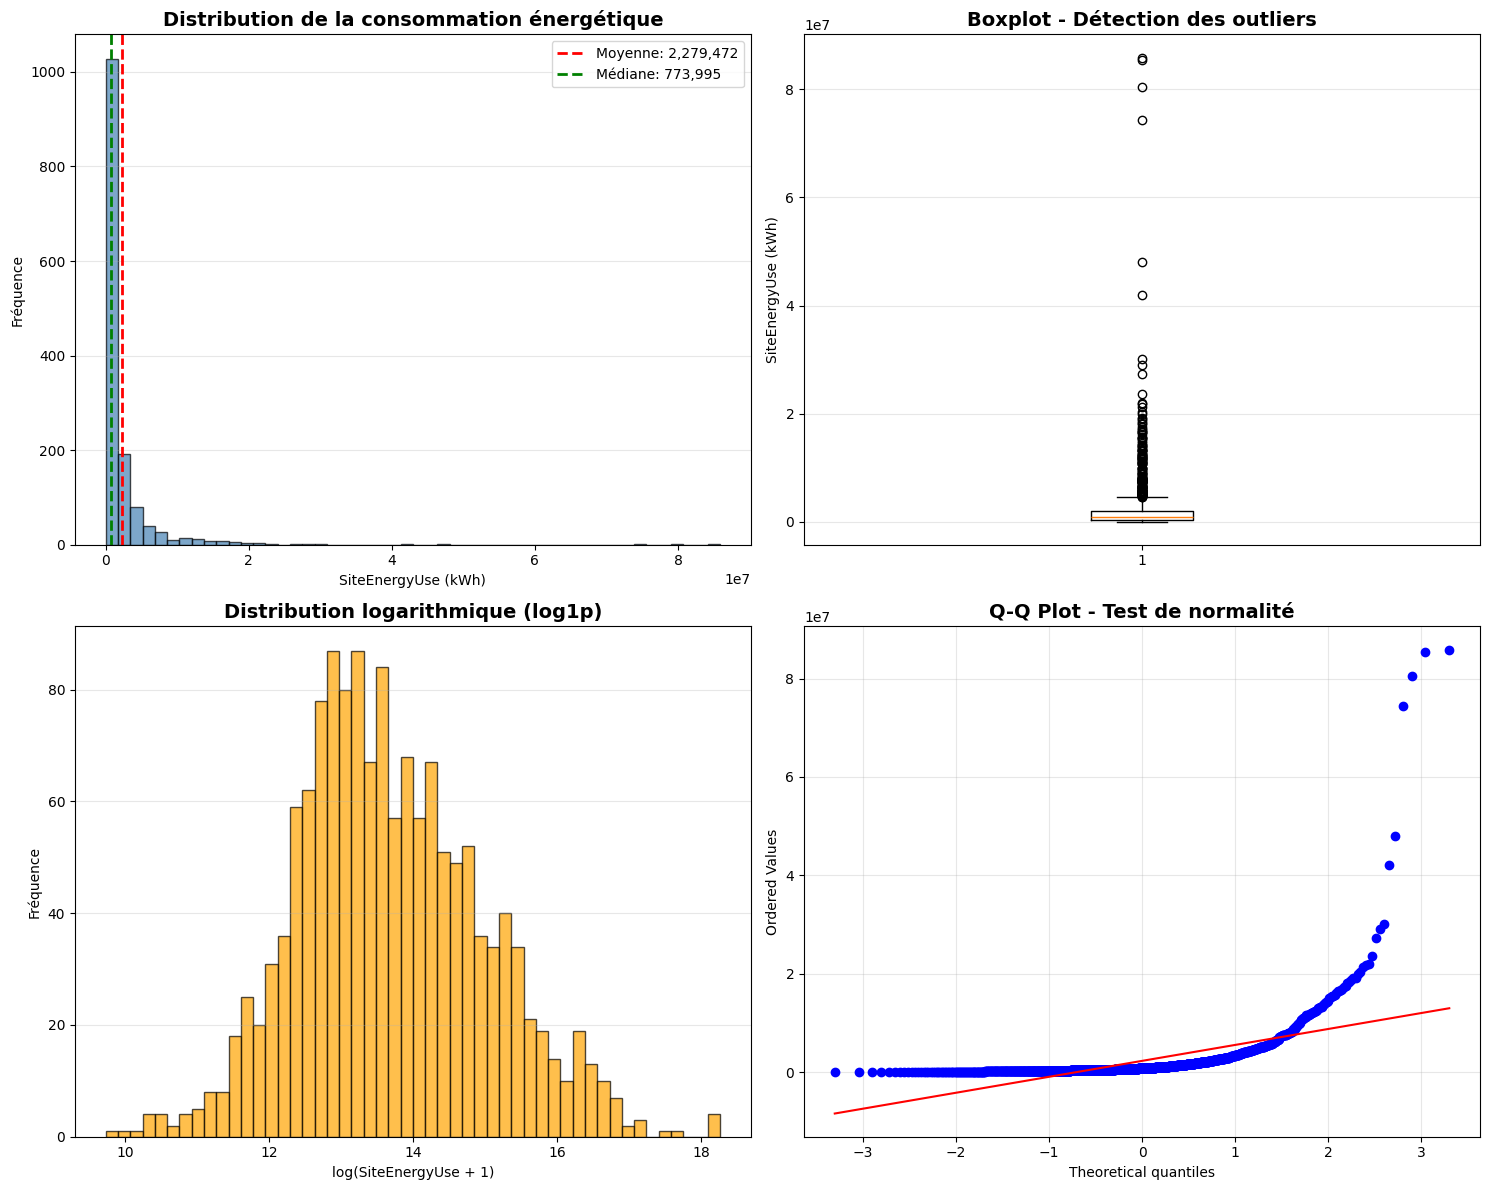

=== ANALYSE DES OUTLIERS : ===

Q1 (25%) : 356,993 kWh
Q3 (75%) : 2,040,382 kWh
IQR : 1,683,389 kWh
Borne inférieure : -2,168,090 kWh
Borne supérieure : 4,565,465 kWh

Nombre d'outliers détectés : 164 (11.38%)
Valeur min des outliers : 4,583,923 kWh
Valeur max des outliers : 85,896,430 kWh


In [167]:
# Appel de la fonction analyser_distribution_cible
print(f"=== ANALYSE DE LA VARIABLE CIBLE : {target} ===\n")
stats_target = analyser_distribution_cible(building_consumption_featured, target)
# Appel de la fonction analyser_outliers
print(f"=== ANALYSE DES OUTLIERS : ===\n")
outliers = analyser_outliers(building_consumption_featured, target)

### 2. Gestion des outliers

In [168]:
print(f"Dataset AVANT suppression : {len(building_consumption_featured)} lignes")

# Supprimer les outliers en utilisant les bornes calculées
building_consumption_featured = building_consumption_featured[
    (building_consumption_featured[target] >= outliers['lower_bound']) & 
    (building_consumption_featured[target] <= outliers['upper_bound'])
]
print(f"Dataset APRÉS suppression : {len(building_consumption_featured)} lignes")

# Vérification finale
print(f"\nDataset final : {building_consumption_featured.shape}")
print(f"Target - Min: {building_consumption_featured[target].min():,.0f} kWh")
print(f"Target - Max: {building_consumption_featured[target].max():,.0f} kWh")
print(f"Target - Moyenne: {building_consumption_featured[target].mean():,.0f} kWh")

Dataset AVANT suppression : 1441 lignes
Dataset APRÉS suppression : 1277 lignes

Dataset final : (1277, 20)
Target - Min: 16,744 kWh
Target - Max: 4,536,940 kWh
Target - Moyenne: 1,038,896 kWh


=== DISTRIBUTION APRÈS SUPPRESSION DES OUTLIERS ===

Statistiques descriptives :
count    1.277000e+03
mean     1.038896e+06
std      1.015855e+06
min      1.674409e+04
25%      3.245148e+05
50%      6.295074e+05
75%      1.429589e+06
max      4.536940e+06
Name: SiteEnergyUse(kWh), dtype: float64

Médiane : 629,507 kWh
Écart-type : 1,015,855 kWh


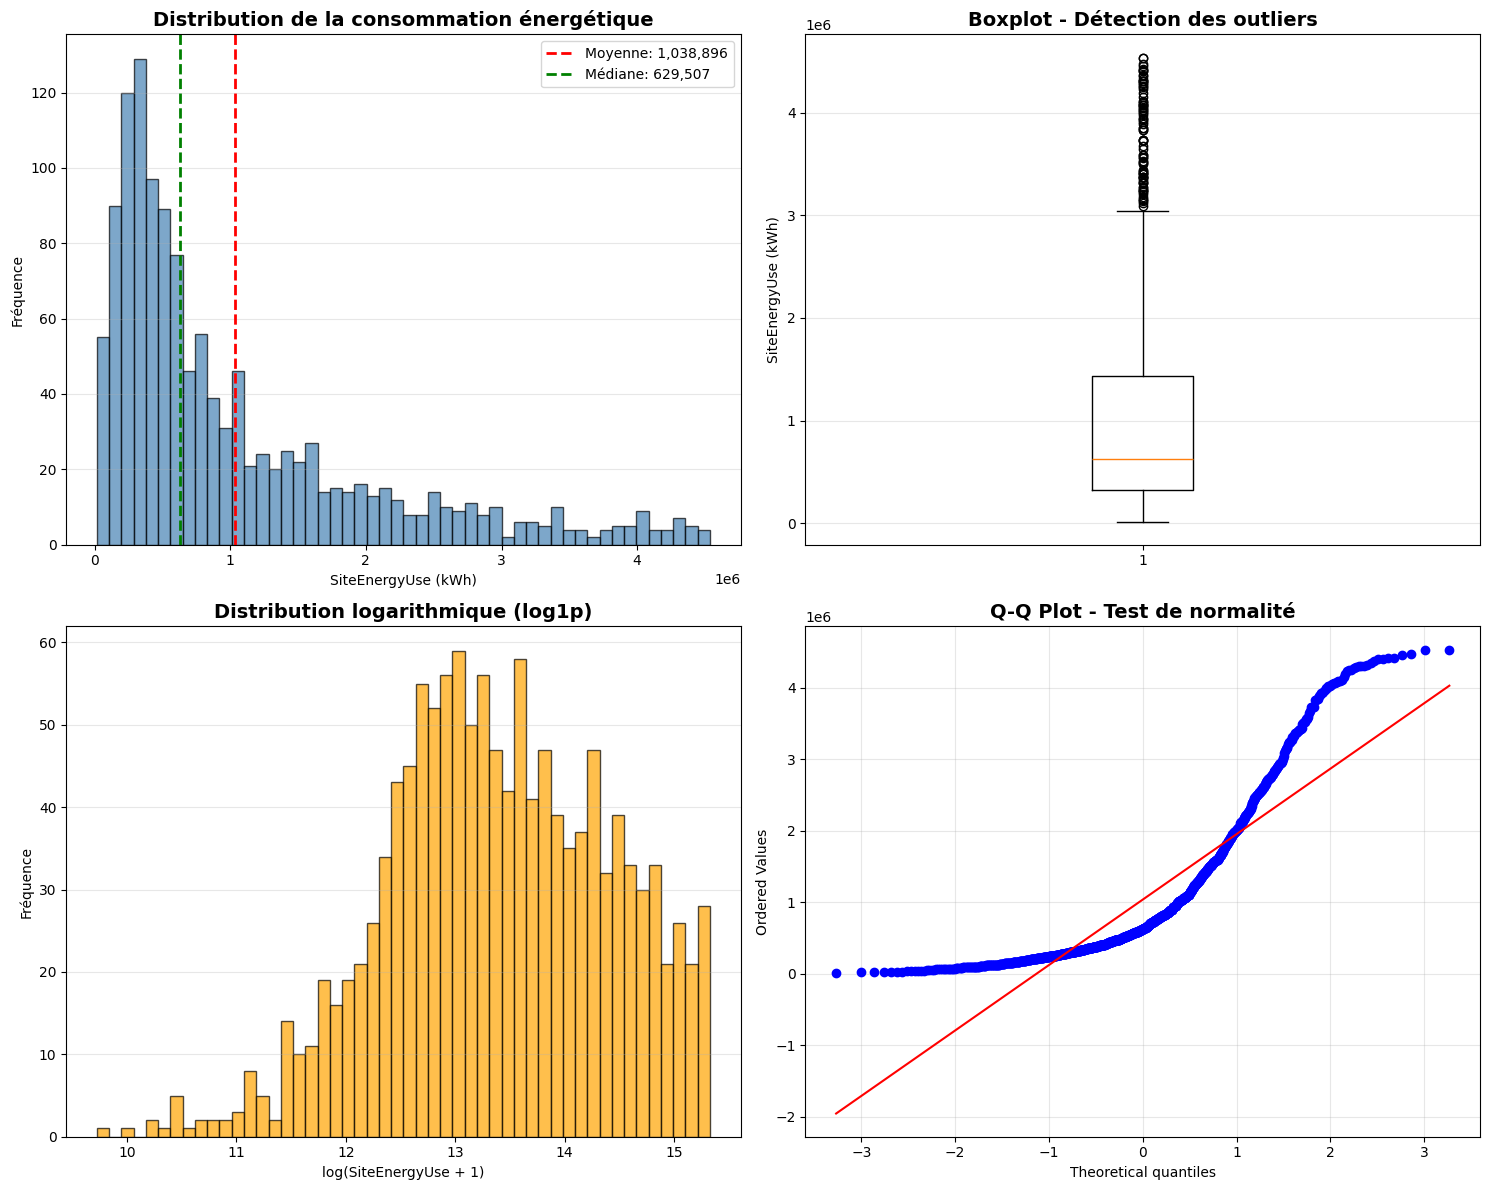

In [169]:
# Réafficher les graphiques sans les outliers
print("=== DISTRIBUTION APRÈS SUPPRESSION DES OUTLIERS ===\n")
stats_target_clean = analyser_distribution_cible(building_consumption_featured, target)

### 3. Analyse des features redondantes

Objectif : Identifier et supprimer les features fortement corrélées entre elles pour éviter la multicolinéarité.

In [170]:
# Identifier les colonnes numériques et catégorielles
numeric_cols = building_consumption_featured.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = building_consumption_featured.select_dtypes(include=['object']).columns.tolist()

print(f"=== TYPES DE FEATURES ===")
print(f"\nFeatures numériques ({len(numeric_cols)}) :")
print(numeric_cols)
print(f"\nFeatures catégorielles ({len(categorical_cols)}) :")
print(categorical_cols)

# Exclure la target et les colonnes à ne pas utiliser pour la modélisation
colonnes_a_exclure = [
    'OSEBuildingID',              # ID (pas prédictif)
    target,                        # Target (SiteEnergyUse(kWh))
    'SiteEUI(kWh/m2)',            # Dérivée de la target (target/surface)
    'Log_SiteEnergyUse',          # Transformation de la target
]

# Features numériques à analyser pour la corrélation
numeric_features = [col for col in numeric_cols if col not in colonnes_a_exclure]

print(f"\n=== FEATURES NUMÉRIQUES POUR ANALYSE DE CORRÉLATION ===")
print(f"Nombre de features : {len(numeric_features)}")
print(numeric_features)

=== TYPES DE FEATURES ===

Features numériques (15) :
['OSEBuildingID', 'YearBuilt', 'PropertyGFATotal', 'PropertyGFABuilding(s)', 'NumberofFloors', 'SiteEnergyUse(kWh)', 'Age_batiment', 'Consommation_par_etage', 'Surface_par_etage', 'Densite_energetique', 'Part_surface_construite', 'Surface_x_Age', 'Etages_x_Age', 'Log_SiteEnergyUse', 'Sqrt_PropertyGFATotal']

Features catégorielles (5) :
['PrimaryPropertyType', 'Categorie_age', 'Taille_batiment', 'Hauteur_batiment', 'Building_Group']

=== FEATURES NUMÉRIQUES POUR ANALYSE DE CORRÉLATION ===
Nombre de features : 12
['YearBuilt', 'PropertyGFATotal', 'PropertyGFABuilding(s)', 'NumberofFloors', 'Age_batiment', 'Consommation_par_etage', 'Surface_par_etage', 'Densite_energetique', 'Part_surface_construite', 'Surface_x_Age', 'Etages_x_Age', 'Sqrt_PropertyGFATotal']


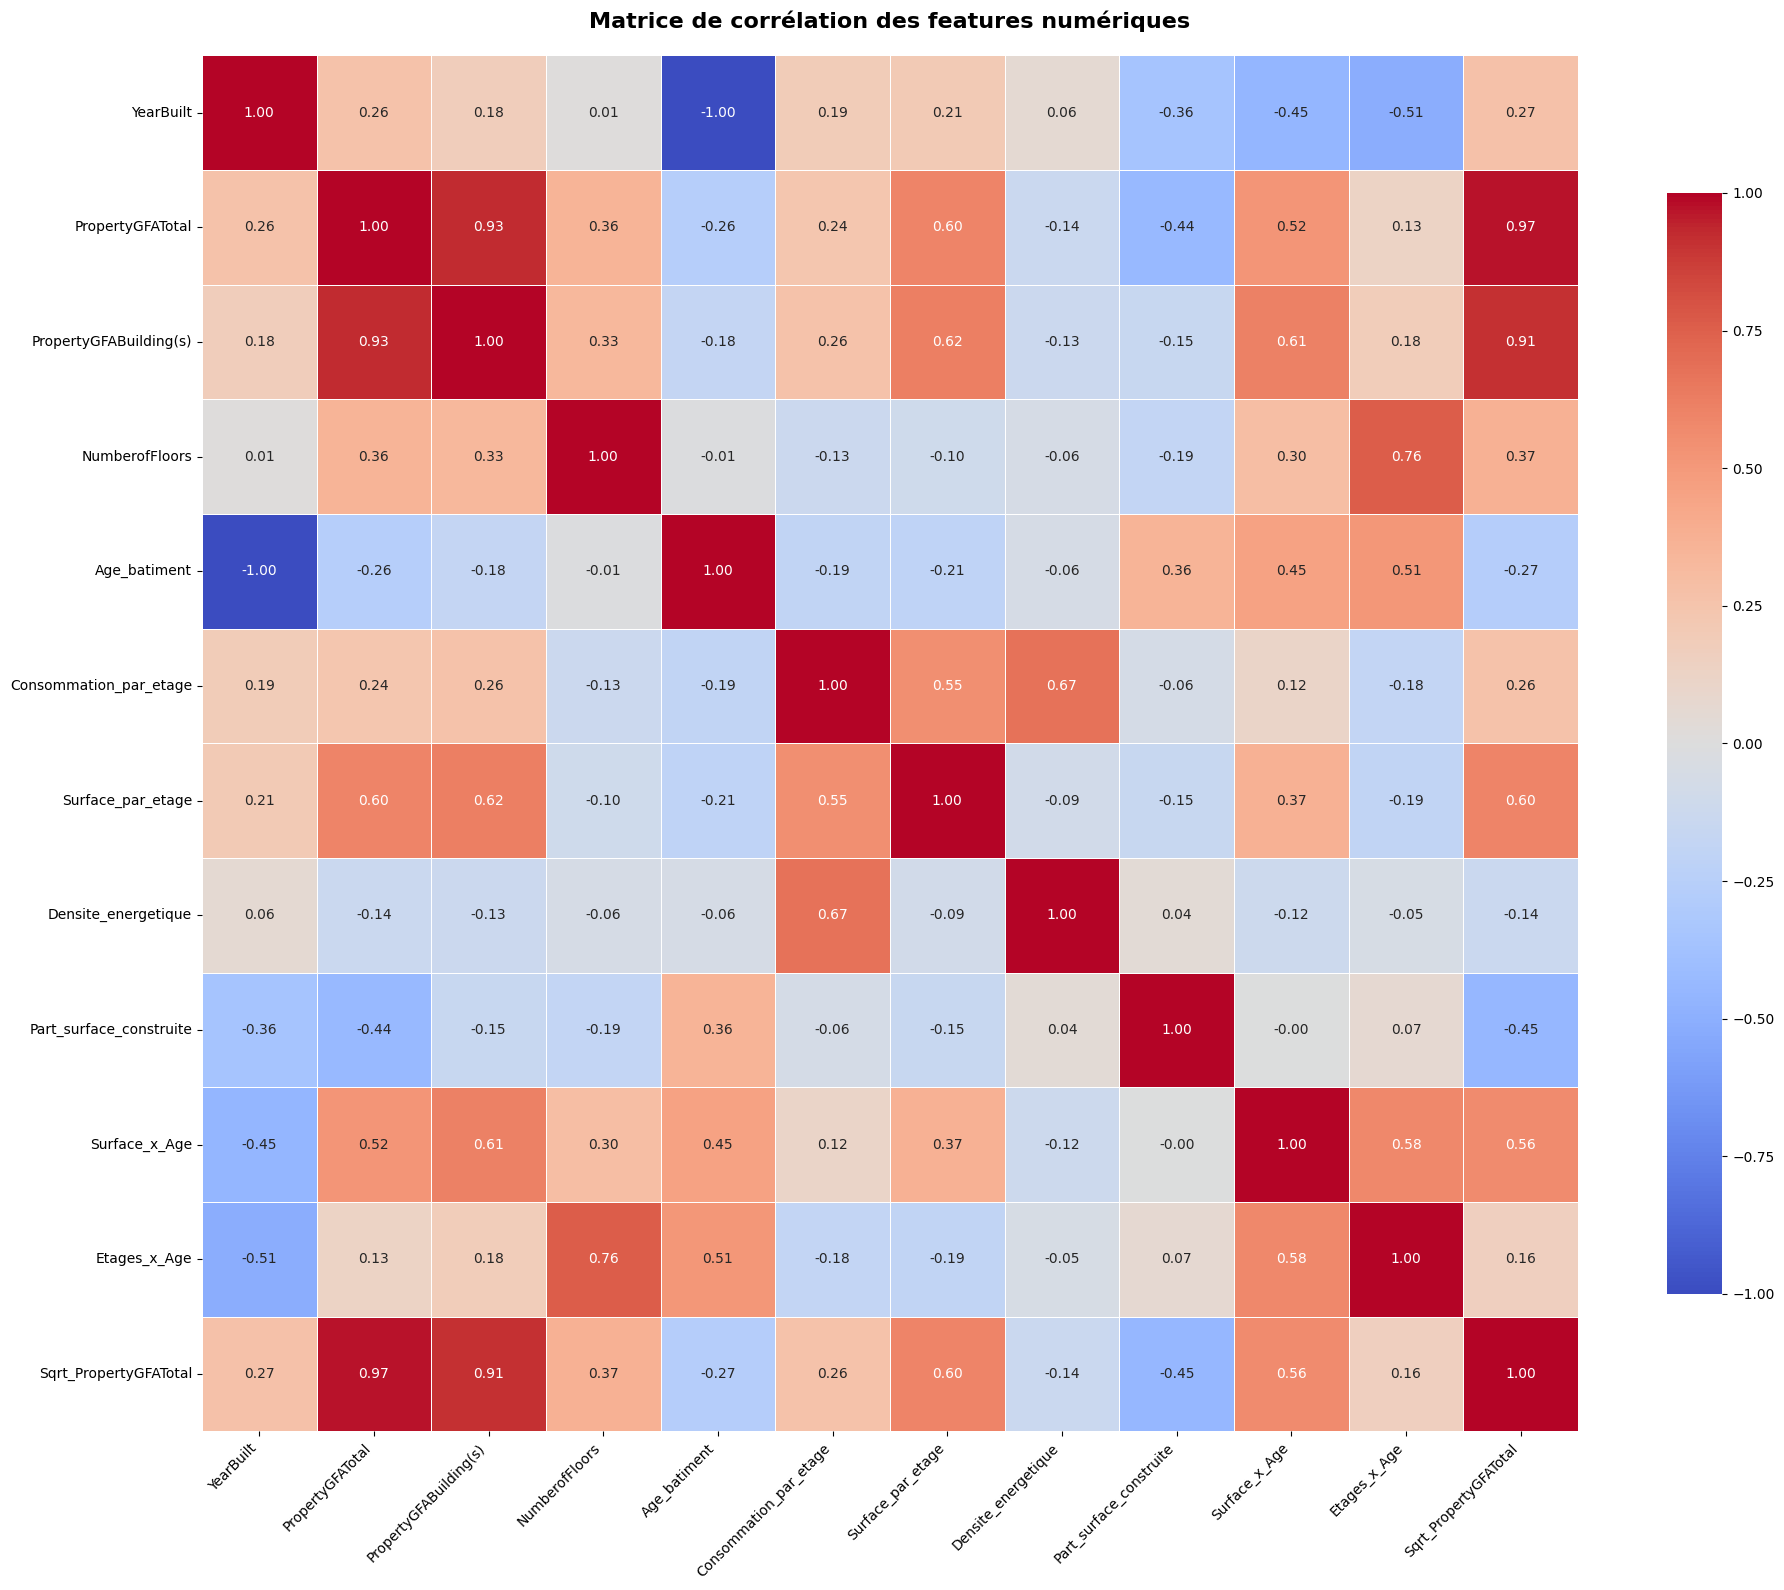


=== FEATURES FORTEMENT CORRÉLÉES (|r| > 0.80) ===
(hors corrélation avec soi-même)



,Feature_1,Feature_2,Correlation
0,YearBuilt,Age_batiment,-1.000000
2,PropertyGFATotal,Sqrt_PropertyGFATotal,0.972640
1,PropertyGFATotal,PropertyGFABuilding(s),0.926728
3,PropertyGFABuilding(s),Sqrt_PropertyGFATotal,0.912589



📊 Nombre de paires fortement corrélées : 4


In [171]:
# Calculer la matrice de corrélation
correlation_matrix = building_consumption_featured[numeric_features].corr()

# Créer une figure pour la matrice de corrélation
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True,          # Afficher les valeurs
            fmt='.2f',           # Format avec 2 décimales
            cmap='coolwarm',     # Palette de couleurs
            center=0,            # Centrer sur 0
            square=True,         # Cellules carrées
            linewidths=0.5,      # Lignes entre cellules
            cbar_kws={"shrink": 0.8})

plt.title('Matrice de corrélation des features numériques', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== FEATURES FORTEMENT CORRÉLÉES (|r| > 0.80) ===")
print("(hors corrélation avec soi-même)\n")

# Trouver les paires de features fortement corrélées
threshold = 0.80
highly_correlated_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            highly_correlated_pairs.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if highly_correlated_pairs:
    df_corr = pd.DataFrame(highly_correlated_pairs).sort_values('Correlation', ascending=False, key=abs)
    display(df_corr)
    
    print(f"\n📊 Nombre de paires fortement corrélées : {len(df_corr)}")
else:
    print("Aucune paire de features avec une corrélation > 0.80")


=== CORRÉLATION AVEC LA TARGET ===

Top 10 features les plus corrélées avec la target :


Consommation_par_etage     0.703923
Sqrt_PropertyGFATotal      0.661651
PropertyGFATotal           0.639057
PropertyGFABuilding(s)     0.610532
Densite_energetique        0.546980
Surface_par_etage          0.361492
Surface_x_Age              0.342574
Part_surface_construite   -0.299571
NumberofFloors             0.290853
Age_batiment              -0.242585
Name: SiteEnergyUse(kWh), dtype: float64


10 features les moins corrélées avec la target :


PropertyGFATotal           0.639057
PropertyGFABuilding(s)     0.610532
Densite_energetique        0.546980
Surface_par_etage          0.361492
Surface_x_Age              0.342574
Part_surface_construite   -0.299571
NumberofFloors             0.290853
Age_batiment              -0.242585
YearBuilt                  0.242585
Etages_x_Age               0.124505
Name: SiteEnergyUse(kWh), dtype: float64

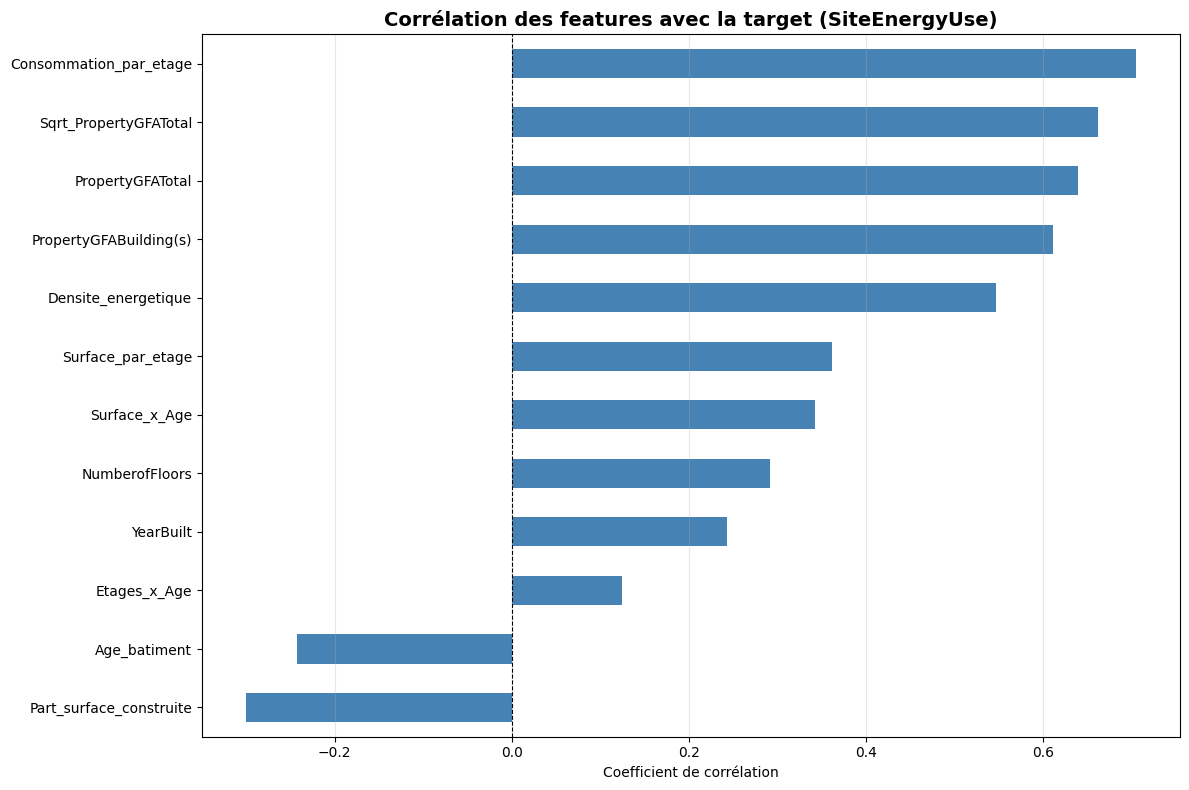

In [172]:
# Analyser aussi la corrélation avec la target
print("\n=== CORRÉLATION AVEC LA TARGET ===")
correlation_with_target = building_consumption_featured[numeric_features + [target]].corr()[target].drop(target).sort_values(ascending=False, key=abs)

print("\nTop 10 features les plus corrélées avec la target :")
display(correlation_with_target.head(10))

print("\n10 features les moins corrélées avec la target :")
display(correlation_with_target.tail(10))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))
correlation_with_target.sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Corrélation des features avec la target (SiteEnergyUse)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient de corrélation')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [173]:
# Définir et supprimer les features à retirer
import re

# Base: liste manuelle issue de l'analyse
features_to_remove = [
    # 1. YearBuilt OU Age_batiment (corrélation -1.00)
    # → Garder Age_batiment (plus intuitif), supprimer YearBuilt
    'YearBuilt',
    
    # 2. PropertyGFATotal vs PropertyGFABuilding(s) vs Sqrt_PropertyGFATotal
    # → Garder PropertyGFATotal (plus simple/utilisé), supprimer doublons
    'PropertyGFABuilding(s)',
    'Sqrt_PropertyGFATotal',
    
    # 3. Très faible corrélation
    'Etages_x_Age',
    
    # 4. Feature négative ou mal définie
    'Part_surface_construite',
]

# Anti-leakage: supprimer dynamiquement toutes les colonnes liées à la consommation/énergie réelle
# (ne doivent JAMAIS être utilisées pour prédire SiteEnergyUse)
risk_pattern = re.compile(r'(electric|kwh|kbtu|naturalgas|gas|steam|fuel|energyuse|eui|ghg)', re.IGNORECASE)
risk_cols = [
    c for c in building_consumption_featured.columns
    if risk_pattern.search(c) and c != target  # NE PAS supprimer la target
]

# Fusionner et dédupliquer
features_to_remove = sorted(set(features_to_remove + risk_cols))

print("=" * 70)
print("FEATURES À SUPPRIMER (manuelles + anti-fuite)")
print("=" * 70)
print(f"\nColonnes détectées comme à risque (anti-fuite): {len(risk_cols)}")
if risk_cols:
    print(risk_cols)

for i, feature in enumerate(features_to_remove, 1):
    print(f"{i}. {feature}")

print(f"\nTotal à supprimer : {len(features_to_remove)} colonnes")

# Appliquer la suppression si présentes
cols_to_drop = [c for c in features_to_remove if c in building_consumption_featured.columns]
building_consumption_featured = building_consumption_featured.drop(columns=cols_to_drop)

print(f"\nSuppression effectuée !")
print(f"Nouvelles dimensions : {building_consumption_featured.shape}")

FEATURES À SUPPRIMER (manuelles + anti-fuite)

Colonnes détectées comme à risque (anti-fuite): 1
['Log_SiteEnergyUse']
1. Etages_x_Age
2. Log_SiteEnergyUse
3. Part_surface_construite
4. PropertyGFABuilding(s)
5. Sqrt_PropertyGFATotal
6. YearBuilt

Total à supprimer : 6 colonnes

Suppression effectuée !
Nouvelles dimensions : (1277, 14)


## 4. Encodage des features catégorielles

Pour utiliser les features catégorielles dans nos modèles de machine learning, nous devons les transformer en valeurs numériques.

**Stratégie d'encodage :**
- **OneHotEncoder** : Pour les variables nominales sans ordre (PrimaryPropertyType, Building_Group)
- **OrdinalEncoder** : Pour les variables ordinales avec ordre naturel (Categorie_age, Taille_batiment, Hauteur_batiment, Efficacite_energetique)

In [174]:
# Identifier les features catégorielles restantes
categorical_features = building_consumption_featured.select_dtypes(include=['object']).columns.tolist()

print("=" * 70)
print("FEATURES CATÉGORIELLES À ENCODER")
print("=" * 70)
print(f"\nNombre de features catégorielles : {len(categorical_features)}")
print(f"Features : {categorical_features}")

# Afficher les valeurs uniques pour chaque feature catégorielle
print("\n" + "=" * 70)
print("VALEURS UNIQUES PAR FEATURE")
print("=" * 70)
for col in categorical_features:
    unique_values = building_consumption_featured[col].unique()
    print(f"\n{col} ({len(unique_values)} valeurs uniques) :")
    print(f"  {unique_values}")

FEATURES CATÉGORIELLES À ENCODER

Nombre de features catégorielles : 5
Features : ['PrimaryPropertyType', 'Categorie_age', 'Taille_batiment', 'Hauteur_batiment', 'Building_Group']

VALEURS UNIQUES PAR FEATURE

PrimaryPropertyType (21 valeurs uniques) :
  ['Hotel' 'Other' 'Mixed Use Property' 'University'
 'Small- and Mid-Sized Office' 'Self-Storage Facility' 'K-12 School'
 'Large Office' 'Retail Store' 'Residence Hall' 'Warehouse'
 'Senior Care Community' 'Worship Facility' 'Supermarket / Grocery Store'
 'Medical Office' 'Distribution Center' 'Laboratory' 'Restaurant'
 'Refrigerated Warehouse' 'Low-Rise Multifamily' 'Hospital']

Categorie_age (4 valeurs uniques) :
  ['Très_ancien' 'Récent' 'Ancien' 'Très_récent']

Taille_batiment (4 valeurs uniques) :
  ['Moyen' 'Grand' 'Petit' 'Très_grand']

Hauteur_batiment (4 valeurs uniques) :
  ['Haut' 'Moyen' 'Bas' 'Très_haut']

Building_Group (7 valeurs uniques) :
  ['Hospitality' 'Other' 'Education' 'Office' 'Storage' 'Retail'
 'Healthcare']


### 4.1 Définir les catégories ordinales

Les features ordinales ont un ordre naturel qu'il faut préserver lors de l'encodage.

In [175]:
# Définir l'ordre pour les features ordinales
# Ces features ont été créées dans le notebook de featuring avec un ordre logique

ordinal_categories = {
    'Categorie_age': ['Très_récent', 'Récent', 'Ancien', 'Très_ancien'], # De plus récent à plus ancien
    'Taille_batiment': ['Petit', 'Moyen', 'Grand', 'Très_grand'],        # De plus petit à plus grand
    'Hauteur_batiment': ['Bas', 'Moyen', 'Haut', 'Très_haut']            # De plus bas à plus haut
}

# Features nominales (sans ordre)
nominal_features = ['PrimaryPropertyType', 'Building_Group']

# Features ordinales
ordinal_features = list(ordinal_categories.keys())

print("=" * 70)
print("STRATÉGIE D'ENCODAGE")
print("=" * 70)
print(f"\nFeatures NOMINALES (OneHotEncoder) : {len(nominal_features)}")
for feat in nominal_features:
    print(f"  - {feat}")
    
print(f"\nFeatures ORDINALES (OrdinalEncoder) : {len(ordinal_features)}")
for feat in ordinal_features:
    print(f"  - {feat}: {ordinal_categories[feat]}")

STRATÉGIE D'ENCODAGE

Features NOMINALES (OneHotEncoder) : 2
  - PrimaryPropertyType
  - Building_Group

Features ORDINALES (OrdinalEncoder) : 3
  - Categorie_age: ['Très_récent', 'Récent', 'Ancien', 'Très_ancien']
  - Taille_batiment: ['Petit', 'Moyen', 'Grand', 'Très_grand']
  - Hauteur_batiment: ['Bas', 'Moyen', 'Haut', 'Très_haut']


### 4.2 Appliquer l'encodage

Nous utilisons `ColumnTransformer` pour appliquer différents encodages selon le type de feature.

In [176]:
# Créer une copie du dataframe pour l'encodage
building_consumption_encoded = building_consumption_featured.copy()

# Encoder les features ORDINALES (préserver l'ordre)
ordinal_encoder = OrdinalEncoder(
    categories=[ordinal_categories[col] for col in ordinal_features],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

building_consumption_encoded[ordinal_features] = ordinal_encoder.fit_transform(building_consumption_encoded[ordinal_features])

print("=" * 70)
print("ENCODAGE DES FEATURES ORDINALES (OrdinalEncoder)")
print("=" * 70)
for i, col in enumerate(ordinal_features):
    print(f"\n{col}:")
    print(f"  Ordre : {ordinal_categories[col]}")
    print(f"  Encodage : 0 → '{ordinal_categories[col][0]}', ..., {len(ordinal_categories[col])-1} → '{ordinal_categories[col][-1]}'")
    print(f"  Valeurs après encodage : {sorted(building_consumption_encoded[col].unique())}")

# Encoder les features NOMINALES (OneHotEncoder)
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded_nominal = onehot_encoder.fit_transform(building_consumption_encoded[nominal_features])

# Créer les noms des nouvelles colonnes
nominal_feature_names = []
for i, col in enumerate(nominal_features):
    categories = onehot_encoder.categories_[i][1:]  # Ignorer la première catégorie (drop='first')
    for cat in categories:
        nominal_feature_names.append(f"{col}_{cat}")

# Créer un DataFrame avec les colonnes encodées
building_consumption_nominal_encoded = pd.DataFrame(
    encoded_nominal, 
    columns=nominal_feature_names,
    index=building_consumption_encoded.index
)

print("\n" + "=" * 70)
print("ENCODAGE DES FEATURES NOMINALES (OneHotEncoder)")
print("=" * 70)
print(f"\nDrop first = True (évite la colinéarité parfaite)")
for col in nominal_features:
    original_categories = building_consumption_featured[col].unique()
    new_cols = [c for c in nominal_feature_names if c.startswith(f"{col}_")]
    print(f"\n{col} ({len(original_categories)} catégories) → {len(new_cols)} colonnes binaires")
    print(f"  Catégories : {original_categories}")
    print(f"  Nouvelles colonnes : {new_cols}")

# Supprimer les colonnes catégorielles originales
building_consumption_encoded = building_consumption_encoded.drop(columns=nominal_features)

# Ajouter les colonnes OneHot encodées
building_consumption_encoded = pd.concat([building_consumption_encoded, building_consumption_nominal_encoded], axis=1)

print("\n" + "=" * 70)
print("RÉSULTAT FINAL")
print("=" * 70)
print(f"\nDataset AVANT encodage : {building_consumption_featured.shape}")
print(f"  - Features numériques : {len(building_consumption_featured.select_dtypes(include=[np.number]).columns)}")
print(f"  - Features catégorielles : {len(building_consumption_featured.select_dtypes(include=['object']).columns)}")

print(f"\nDataset APRÈS encodage : {building_consumption_encoded.shape}")
print(f"  - Toutes les colonnes sont maintenant numériques")
print(f"  - Nouvelles features OneHot créées : {len(nominal_feature_names)}")
print(f"  - Features ordinales encodées : {len(ordinal_features)}")

print(f"\n✓ Dataset encodé sauvegardé dans 'building_consumption_encoded'")

ENCODAGE DES FEATURES ORDINALES (OrdinalEncoder)

Categorie_age:
  Ordre : ['Très_récent', 'Récent', 'Ancien', 'Très_ancien']
  Encodage : 0 → 'Très_récent', ..., 3 → 'Très_ancien'
  Valeurs après encodage : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Taille_batiment:
  Ordre : ['Petit', 'Moyen', 'Grand', 'Très_grand']
  Encodage : 0 → 'Petit', ..., 3 → 'Très_grand'
  Valeurs après encodage : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Hauteur_batiment:
  Ordre : ['Bas', 'Moyen', 'Haut', 'Très_haut']
  Encodage : 0 → 'Bas', ..., 3 → 'Très_haut'
  Valeurs après encodage : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

ENCODAGE DES FEATURES NOMINALES (OneHotEncoder)

Drop first = True (évite la colinéarité parfaite)

PrimaryPropertyType (21 catégories) → 20 colonnes binaires
  Catégories : ['Hotel' 'Other' 'Mixed Use Property' 'University'
 'Small- and Mid-Sized Office' 'Self-Storage Facility' 'K-12 School'
 'Larg

=== DISTRIBUTION APRÈS ENCODAGE ===

Statistiques descriptives :
count    1.277000e+03
mean     1.038896e+06
std      1.015855e+06
min      1.674409e+04
25%      3.245148e+05
50%      6.295074e+05
75%      1.429589e+06
max      4.536940e+06
Name: SiteEnergyUse(kWh), dtype: float64

Médiane : 629,507 kWh
Écart-type : 1,015,855 kWh


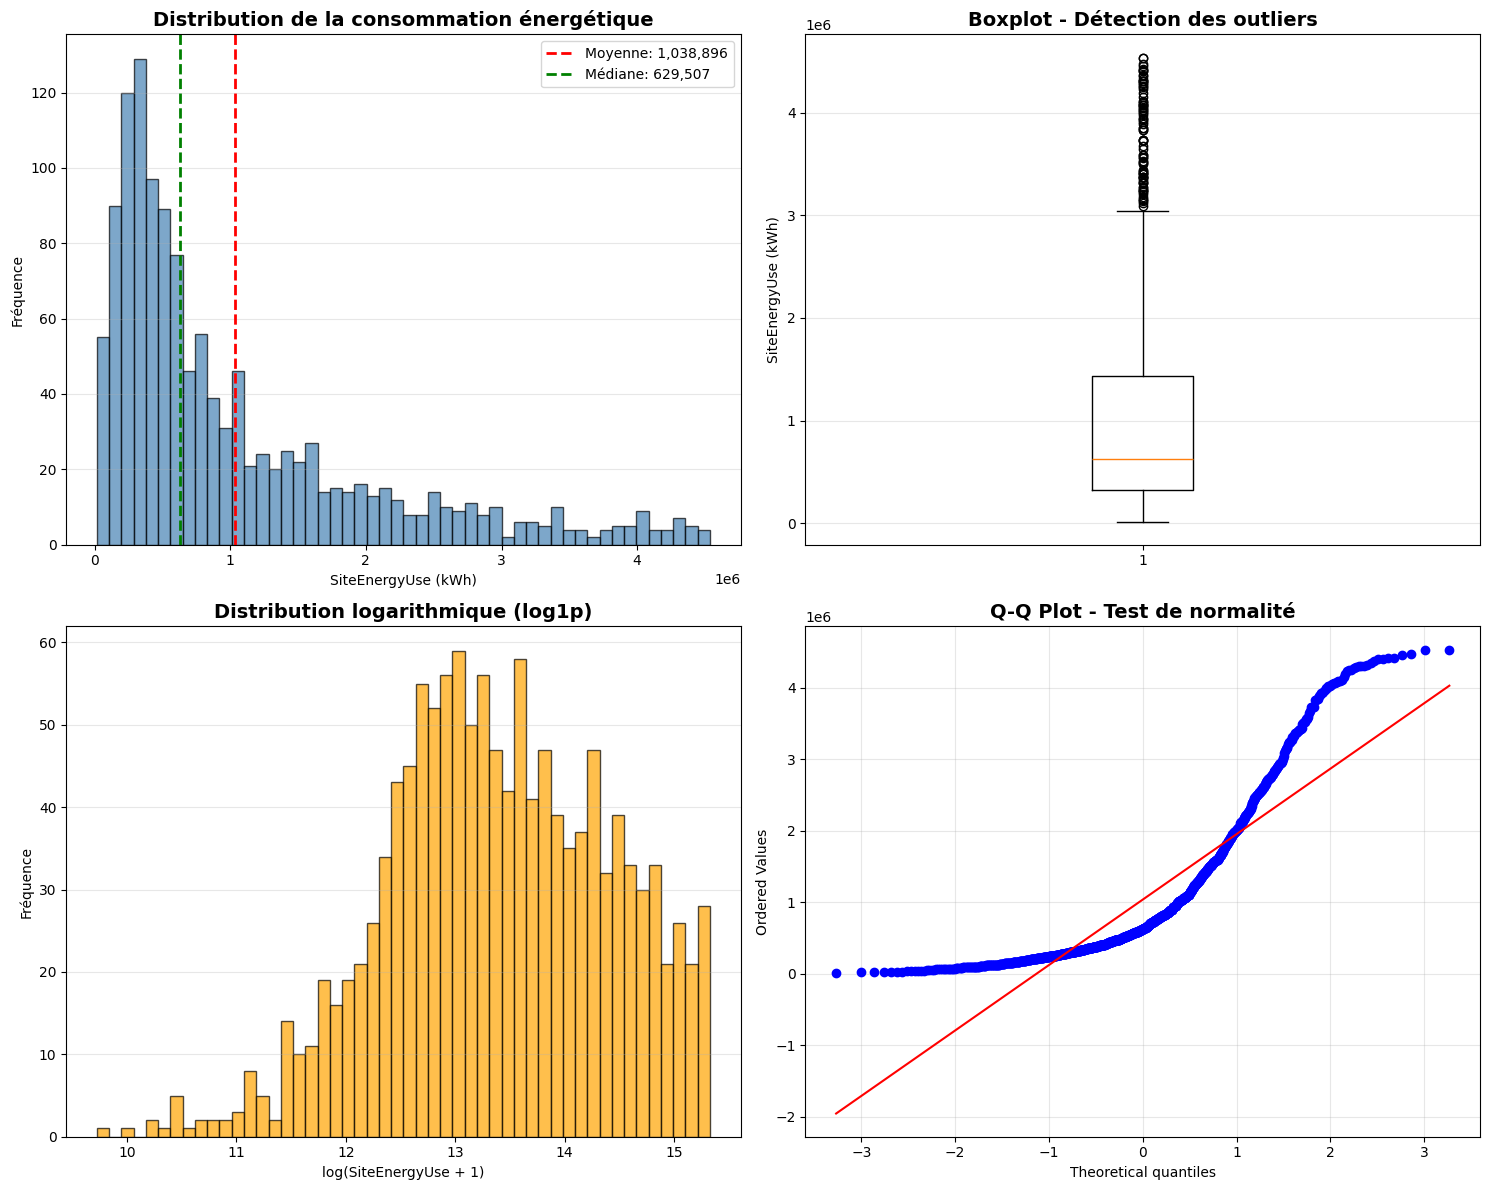

In [177]:
# Réafficher les graphiques sans les outliers
print("=== DISTRIBUTION APRÈS ENCODAGE ===\n")
stats_target_clean = analyser_distribution_cible(building_consumption_encoded, target)

In [178]:
# On sauvegarde le dataset encodé pour la modélisation
building_consumption_encoded.to_csv('../sources/2016_Building_Energy_Benchmarking_03_encoded.csv', index=False)
display(building_consumption_encoded.head())

,OSEBuildingID,PropertyGFATotal,NumberofFloors,SiteEnergyUse(kWh),Age_batiment,Categorie_age,Consommation_par_etage,Surface_par_etage,Densite_energetique,Taille_batiment,...,PrimaryPropertyType_Supermarket / Grocery Store,PrimaryPropertyType_University,PrimaryPropertyType_Warehouse,PrimaryPropertyType_Worship Facility,Building_Group_Healthcare,Building_Group_Hospitality,Building_Group_Office,Building_Group_Other,Building_Group_Retail,Building_Group_Storage
0,1,88434,12,2.117838e+06,89,3.0,162910.599237,6802.615385,23.947959,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,103566,11,2.458260e+06,20,1.0,204855.041617,8630.500000,23.735944,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,5,61320,10,1.991296e+06,90,3.0,181026.909371,5574.545455,32.473313,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,8,175580,18,4.153581e+06,36,2.0,218609.516058,9241.052632,23.656209,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,10,83008,11,1.687736e+06,90,3.0,140644.684380,6917.333333,20.331967,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 5. Séparation features (X) et target (y)

Nous allons maintenant séparer notre dataset en :
- **X** : DataFrame contenant toutes les features pour la prédiction
- **y** : Series contenant la variable cible (SiteEnergyUse(kWh))

In [179]:
# Séparation features (X) et target (y) avec garde anti-fuite
import re

# Définir les colonnes à exclure des features
colonnes_a_exclure_modeling = [
    'OSEBuildingID',              # ID du bâtiment (pas prédictif)
    target,                       # Target (SiteEnergyUse(kWh))
    'SiteEUI(kWh/m2)',            # Dérivée de la target (target/surface)
    'Log_SiteEnergyUse',          # Transformation de la target
    'Electricity(kWh)',
    'NaturalGas(kWh)'
]

# Extraire y (target)
y = building_consumption_encoded[target].copy()

# Extraire X (features) - Supprimer la target et les colonnes non-prédictives
X = building_consumption_encoded.drop(columns=[c for c in colonnes_a_exclure_modeling if c in building_consumption_encoded.columns])

# Garde anti-fuite supplémentaire (au cas où une colonne risquée subsisterait après encodage)
risk_pattern = re.compile(r'(electric|kwh|kbtu|naturalgas|gas|steam|fuel|energyuse|eui|ghg)', re.IGNORECASE)
risky_in_X = [c for c in X.columns if risk_pattern.search(c)]
if risky_in_X:
    print(f"\n⚠️ Colonnes risquées détectées dans X (anti-fuite) → suppression: {len(risky_in_X)}")
    print(risky_in_X[:20], ("…" if len(risky_in_X) > 20 else ""))
    X = X.drop(columns=risky_in_X)

print("\n" + "=" * 70)
print("SÉPARATION X / y EFFECTUÉE (anti-fuite)")
print("=" * 70)
print(f"\nDataset complet : {building_consumption_encoded.shape}")
print(f"\nX (features) : {X.shape}")
print(f"  - Nombre de lignes : {X.shape[0]}")
print(f"  - Nombre de features : {X.shape[1]}")

print(f"\ny (target) : {target}")
print(f"  - Nombre d'observations : {len(y)}")


SÉPARATION X / y EFFECTUÉE (anti-fuite)

Dataset complet : (1277, 38)

X (features) : (1277, 36)
  - Nombre de lignes : 1277
  - Nombre de features : 36

y (target) : SiteEnergyUse(kWh)
  - Nombre d'observations : 1277


In [180]:
# On enregistre X et y pour la modélisation
X.to_csv('../sources/2016_Building_Energy_Benchmarking_03X_building_consumption.csv', index=False)
y.to_csv('../sources/2016_Building_Energy_Benchmarking_03y_building_consumption.csv', index=False)

### 6. Normalisaiton des données

**Méthode utilisée : StandardScaler**
- Transforme chaque feature pour avoir une moyenne = 0 et un écart-type = 1

**Important** : On normalise uniquement **X (features)**, pas **y (target)**.

#### 6.1 Standardisation avec StandardScaler

In [181]:
# Créer le scaler
scaler = StandardScaler()

# Ajuster le scaler sur X et transformer
X_scaled = scaler.fit_transform(X)

# Convertir en DataFrame pour garder les noms de colonnes
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("=" * 70)
print("NORMALISATION DES FEATURES")
print("=" * 70)
print(f"\nDimensions de X_scaled : {X_scaled.shape}")
print(f"\nVérification de la normalisation (premières features) :")
print(f"  Moyennes (doivent être ~0) :")
for col in X_scaled.columns[:5]:
    print(f"    {col}: {X_scaled[col].mean():.10f}")
print(f"\n  Écarts-types (doivent être ~1) :")
for col in X_scaled.columns[:5]:
    print(f"    {col}: {X_scaled[col].std():.10f}")

NORMALISATION DES FEATURES

Dimensions de X_scaled : (1277, 36)

Vérification de la normalisation (premières features) :
  Moyennes (doivent être ~0) :
    PropertyGFATotal: 0.0000000000
    NumberofFloors: -0.0000000000
    Age_batiment: 0.0000000000
    Categorie_age: 0.0000000000
    Consommation_par_etage: -0.0000000000

  Écarts-types (doivent être ~1) :
    PropertyGFATotal: 1.0003917728
    NumberofFloors: 1.0003917728
    Age_batiment: 1.0003917728
    Categorie_age: 1.0003917728
    Consommation_par_etage: 1.0003917728


In [182]:
# Sauvegarder X_scaled pour la modélisation
X_scaled.to_csv('../sources/2016_Building_Energy_Benchmarking_03X_scaled_building_consumption.csv', index=False)

In [183]:
# Debug: vérifier la présence de la target après encodage
print('target =', target)
print('target in encoded columns?', target in building_consumption_encoded.columns)
print('encoded columns count =', len(building_consumption_encoded.columns))
print('some columns:', list(building_consumption_encoded.columns)[:20])


target = SiteEnergyUse(kWh)
target in encoded columns? True
encoded columns count = 38
some columns: ['OSEBuildingID', 'PropertyGFATotal', 'NumberofFloors', 'SiteEnergyUse(kWh)', 'Age_batiment', 'Categorie_age', 'Consommation_par_etage', 'Surface_par_etage', 'Densite_energetique', 'Taille_batiment', 'Hauteur_batiment', 'Surface_x_Age', 'PrimaryPropertyType_Hospital', 'PrimaryPropertyType_Hotel', 'PrimaryPropertyType_K-12 School', 'PrimaryPropertyType_Laboratory', 'PrimaryPropertyType_Large Office', 'PrimaryPropertyType_Low-Rise Multifamily', 'PrimaryPropertyType_Medical Office', 'PrimaryPropertyType_Mixed Use Property']


In [184]:
# Debug: présence de la target dans building_consumption_featured ?
print('target in featured columns?', target in building_consumption_featured.columns)
print('featured columns count =', len(building_consumption_featured.columns))
print('sample columns:', list(building_consumption_featured.columns)[:20])


target in featured columns? True
featured columns count = 14
sample columns: ['OSEBuildingID', 'PrimaryPropertyType', 'PropertyGFATotal', 'NumberofFloors', 'SiteEnergyUse(kWh)', 'Age_batiment', 'Categorie_age', 'Consommation_par_etage', 'Surface_par_etage', 'Densite_energetique', 'Taille_batiment', 'Hauteur_batiment', 'Surface_x_Age', 'Building_Group']
